In [ ]:
#Environment Handshake & Authentication
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# 1. Point securely to your JSON authorization key file
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/home/taijl/DSAI/S2_BigData/DSAI_HDB_Project/project-8d552288-1acb-4a23-893-07fe8627d11f.json"

# 2. Build the SQLAlchemy cloud-hosted database connection engine
PROJECT_ID = "project-8d552288-1acb-4a23-893"
engine = create_engine(f"bigquery://{PROJECT_ID}/hdb_analytics_marts")

In [6]:
# Relational Sat Schema Feature Extraction
query = """
SELECT
    f.resale_price,
    f.floor_area_sqm,
    f.price_per_sqm,
    f.price_per_sqft,
    f.remaining_lease_years,
    f.min_distance_to_regional_hub_km,
    f.dist_to_closest_shopping_mall_km,
    f.dist_to_closest_primary_school_km,
    f.dist_to_closest_mrt_km,
    f.dist_to_closest_lrt_km,
    f.transaction_month,
    f.storey_range,
    f.flat_type,
    p.town,
    p.flat_model
FROM fact_sales f
LEFT JOIN dim_properties p ON f.property_id = p.property_id
"""
print("🚀 Streaming master warehouse dataset from BigQuery...")
df = pd.read_sql(query, con=engine)

print(f"📊 Extraction Complete! Loaded {df.shape[0]:,} rows x {df.shape[1]} columns.")


🚀 Streaming master warehouse dataset from BigQuery...
📊 Extraction Complete! Loaded 231,971 rows x 15 columns.


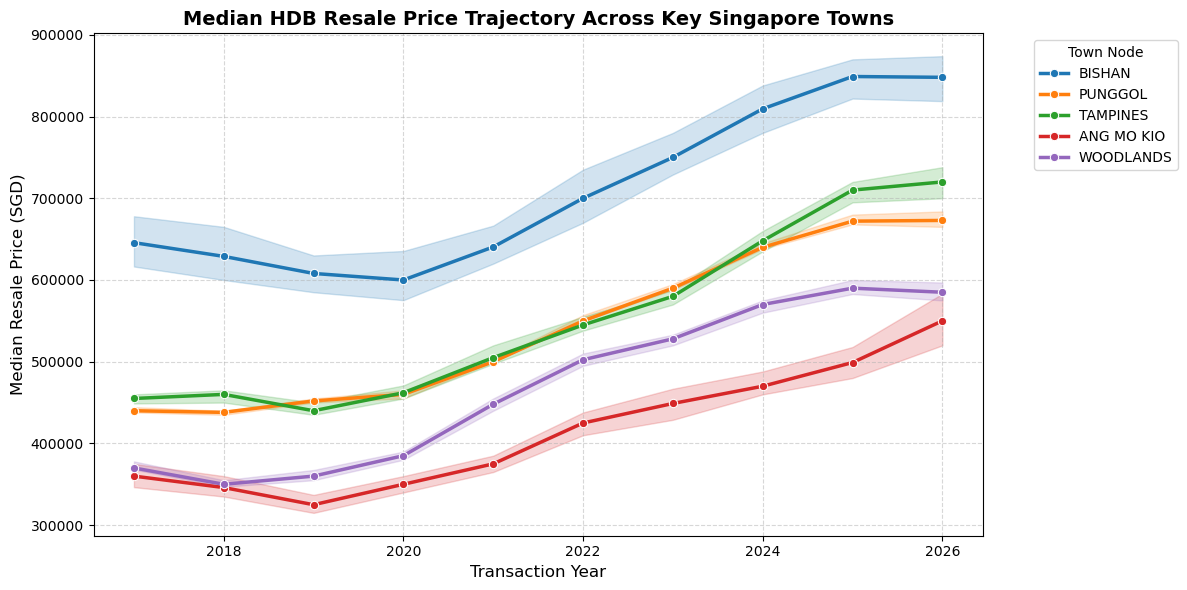

In [7]:
# 3. Insight 1 - Macro Price Fluctuations Across Towns

# Isolate transaction year integers for chronological tracking
df['transaction_year'] = df['transaction_month'].str.split('-').str[0].astype(int)

plt.figure(figsize=(12,6))

# Filter for rep towns to maintain chart 
target_towns = ['BISHAN','ANG MO KIO', 'PUNGGOL', 'TAMPINES', 'WOODLANDS']
df_filtered = df[df['town'].isin(target_towns)]

sns.lineplot(data=df_filtered,x='transaction_year', y='resale_price',hue='town', estimator='median',marker='o',linewidth=2.5)
plt.title('Median HDB Resale Price Trajectory Across Key Singapore Towns', fontsize = 14, fontweight='bold')
plt.xlabel('Transaction Year', fontsize= 12)
plt.ylabel("Median Resale Price (SGD)", fontsize = 12)
plt.grid(True, linestyle="--",alpha=0.5)
plt.legend(title='Town Node', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

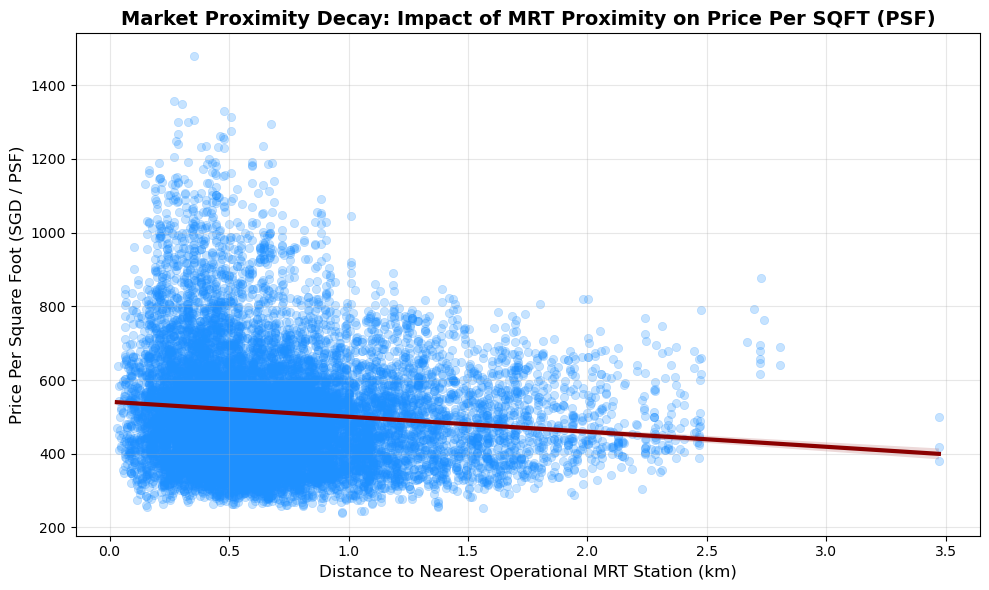

In [8]:
# Insight 2 - Transport Accessibility Proximity Decay

plt.figure(figsize=(10,6))
# sample data points to speed up chart rendering
df_sample = df.sample(15000,random_state=42)

sns.scatterplot(data=df_sample,x='dist_to_closest_mrt_km', y='price_per_sqft', alpha=0.25, color='dodgerblue', edgecolor=None)
sns.regplot(data=df_sample, x='dist_to_closest_mrt_km', y='price_per_sqft', scatter=False, color='darkred', line_kws={"linewidth": 3})

plt.title('Market Proximity Decay: Impact of MRT Proximity on Price Per SQFT (PSF)', fontsize=14, fontweight='bold')
plt.xlabel('Distance to Nearest Operational MRT Station (km)', fontsize=12)
plt.ylabel('Price Per Square Foot (SGD / PSF)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

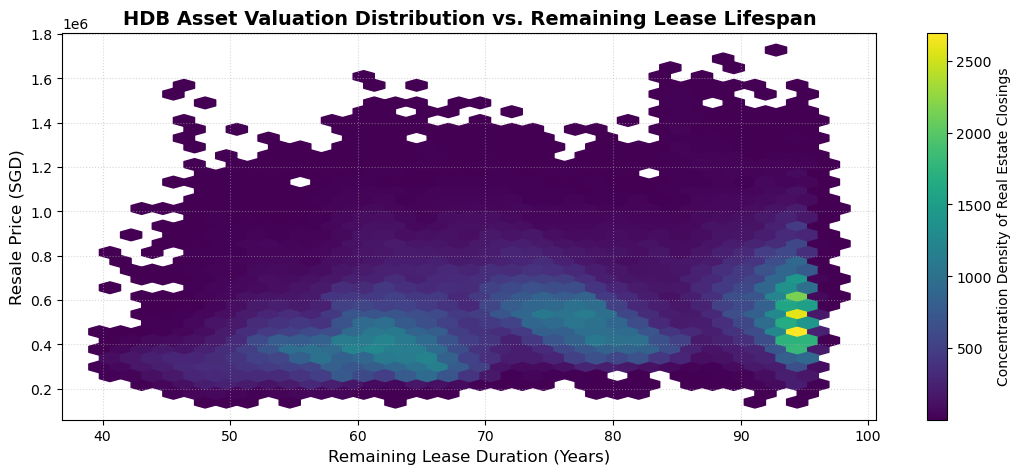

In [9]:
plt.figure(figsize=(11, 5))
# Generate a dense hexbin grid to capture value clustering patterns clearly
hb = plt.hexbin(data=df, x='remaining_lease_years', y='resale_price', gridsize=35, cmap='viridis', mincnt=1)
cb = plt.colorbar(hb, label='Concentration Density of Real Estate Closings')

plt.title('HDB Asset Valuation Distribution vs. Remaining Lease Lifespan', fontsize=14, fontweight='bold')
plt.xlabel('Remaining Lease Duration (Years)', fontsize=12)
plt.ylabel('Resale Price (SGD)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


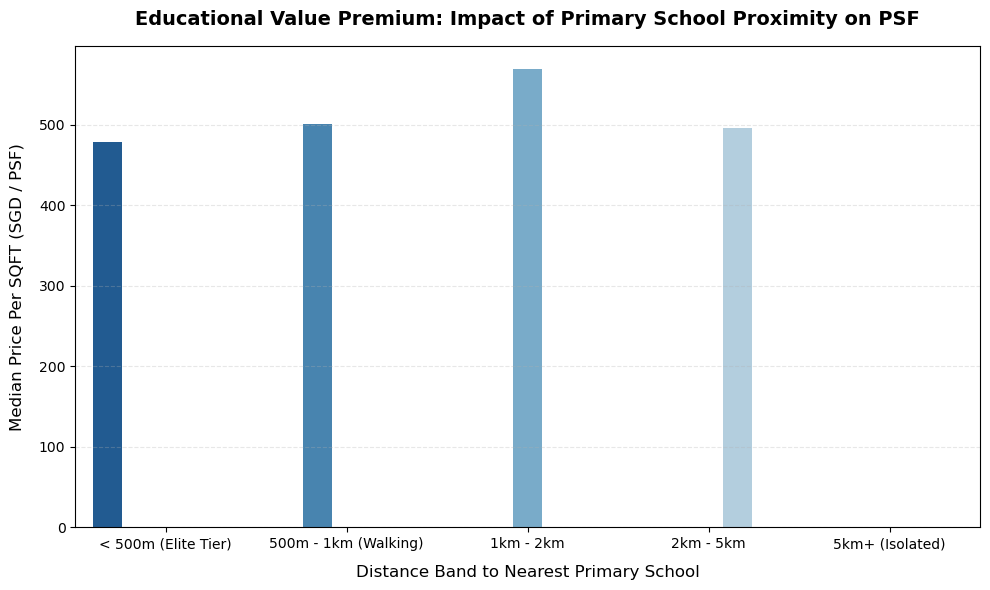

In [10]:
# The Primary School Proximity Premium

# 1. Create categorical distance bands (bins) for proximity sorting
bins = [0, 0.5, 1.0, 2.0, 5.0, np.inf]
labels = ['< 500m (Elite Tier)', '500m - 1km (Walking)', '1km - 2km', '2km - 5km', '5km+ (Isolated)']
df['school_distance_tier'] = pd.cut(df['dist_to_closest_primary_school_km'], bins=bins, labels=labels)

# 2. Render Plot Layout
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df, 
    x='school_distance_tier', 
    y='price_per_sqft', 
    estimator=np.median, 
    palette='Blues_r', 
    hue='school_distance_tier', 
    legend=False,
    errorbar=None
)

plt.title('Educational Value Premium: Impact of Primary School Proximity on PSF', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Distance Band to Nearest Primary School', fontsize=12, labelpad=10)
plt.ylabel('Median Price Per SQFT (SGD / PSF)', fontsize=12, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

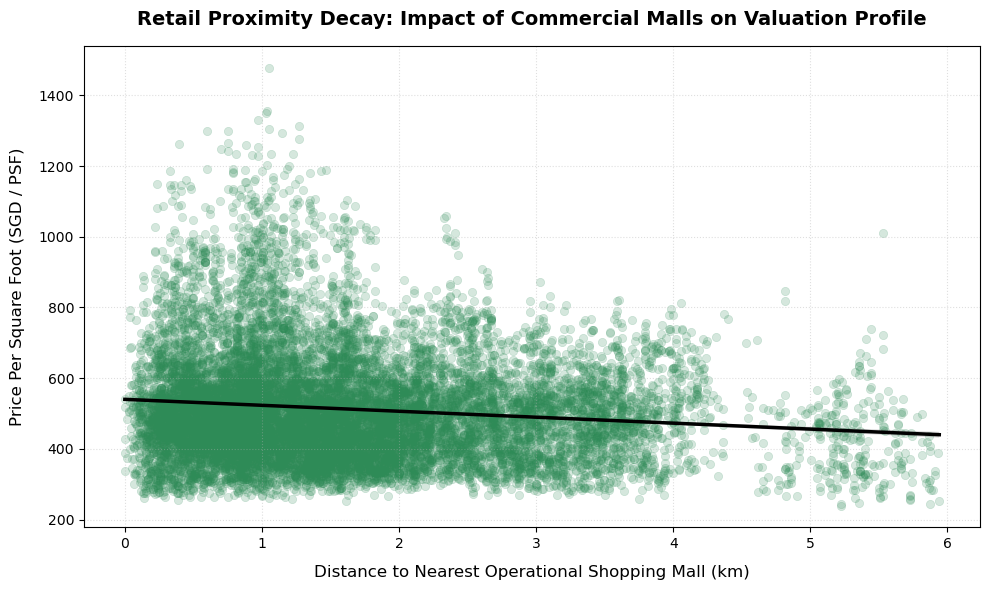

In [12]:
# Shopping Mall Density Proximity Decay

plt.figure(figsize=(10, 6))

# Sample 15,000 nodes to maximize processing speeds and prevent canvas oversaturation
df_mall_sample = df.sample(15000, random_state=42)

sns.scatterplot(
    data=df_mall_sample, 
    x='dist_to_closest_shopping_mall_km', 
    y='price_per_sqft', 
    alpha=0.2, 
    color='seagreen', 
    edgecolor=None
)

# Overlay trendline to show value decay over distance
sns.regplot(
    data=df_mall_sample, 
    x='dist_to_closest_shopping_mall_km', 
    y='price_per_sqft', 
    scatter=False, 
    color='black', 
    line_kws={"linewidth": 2.5, "linestyle": "-"}
)

plt.title('Retail Proximity Decay: Impact of Commercial Malls on Valuation Profile', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Distance to Nearest Operational Shopping Mall (km)', fontsize=12, labelpad=10)
plt.ylabel('Price Per Square Foot (SGD / PSF)', fontsize=12, labelpad=10)
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

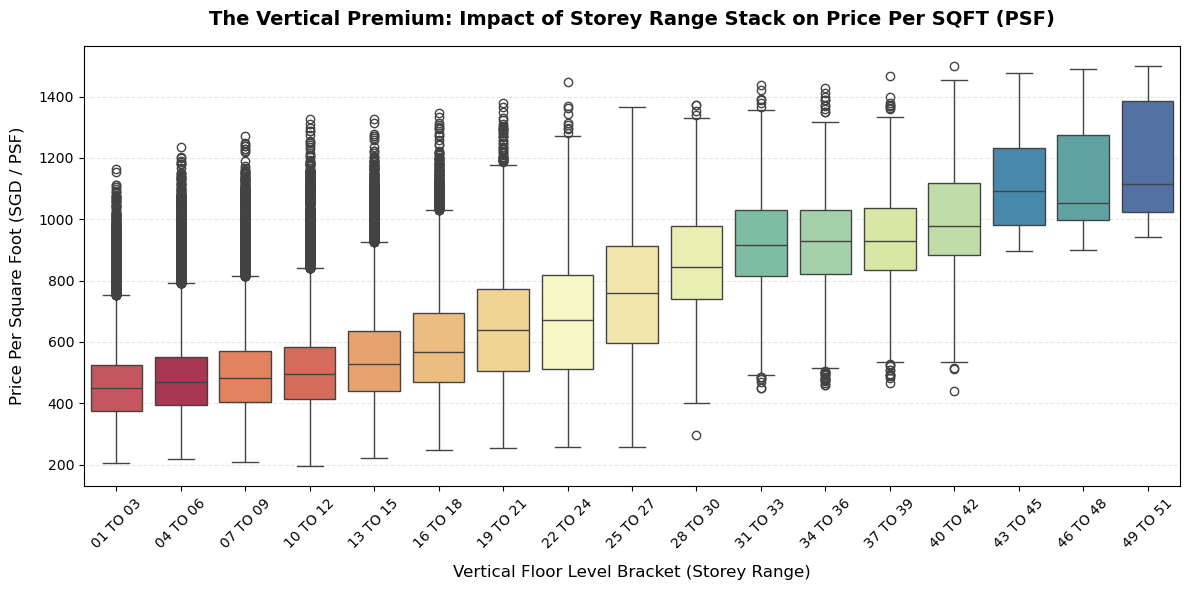

In [13]:
# Add the Storey Range Chart to Your Notebook

# 1. Cleanly sort the storey range index so brackets read low -> high chronologically
storey_order = sorted(df['storey_range'].unique(), key=lambda x: int(x.split(' TO ')[0]))

# 2. Render Plot Layout
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df, 
    x='storey_range', 
    y='price_per_sqft', 
    order=storey_order,
    palette='Spectral',
    hue='storey_range',
    legend=False
)

plt.title('The Vertical Premium: Impact of Storey Range Stack on Price Per SQFT (PSF)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Vertical Floor Level Bracket (Storey Range)', fontsize=12, labelpad=10)
plt.ylabel('Price Per Square Foot (SGD / PSF)', fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


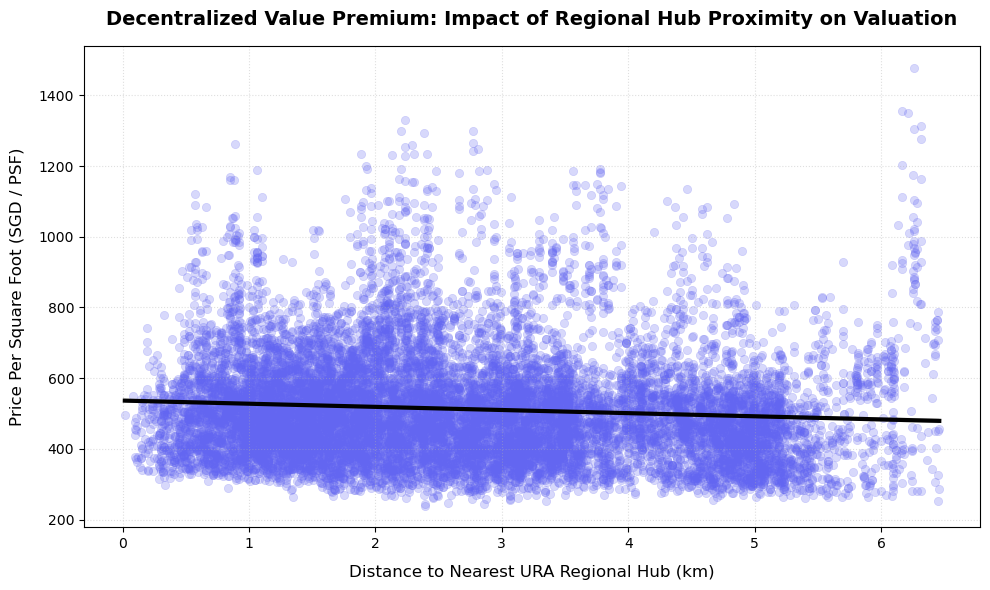

In [14]:
# Add the Regional Hub Decay Chart to Your Notebook
plt.figure(figsize=(10, 6))
# Sample data points to ensure swift canvas rendering performance
df_hub_sample = df.sample(15000, random_state=42)

sns.scatterplot(
    data=df_hub_sample, 
    x='min_distance_to_regional_hub_km', 
    y='price_per_sqft', 
    alpha=0.25, 
    color='#6366f1',  # A sleek Indigo/Violet hex code
    edgecolor=None
)

# Overlay trendline to show the decentralization slope
sns.regplot(
    data=df_hub_sample, 
    x='min_distance_to_regional_hub_km', 
    y='price_per_sqft', 
    scatter=False, 
    color='black', 
    line_kws={"linewidth": 3}
)

plt.title('Decentralized Value Premium: Impact of Regional Hub Proximity on Valuation', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Distance to Nearest URA Regional Hub (km)', fontsize=12, labelpad=10)
plt.ylabel('Price Per Square Foot (SGD / PSF)', fontsize=12, labelpad=10)
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()